<div class="alert alert-block alert-info">
<b>¡Hola! Paula ¿Cómo vas? 👋</b>

Mi nombre es Santiago Sierra. Un gusto acompañarte en este proyecto del Sprint 5 sobre movilidad urbana y productividad económica.

Antes de empezar, te comparto cómo funciona la modalidad de revisión:
<ul>
<li>Cuando encuentre un error, lo señalaré para que lo detectes y lo corrijas por tu cuenta. También iré dejando observaciones sobre tu código y tus conclusiones.</li>
<li>Si en algún punto no logras resolver algo, en la siguiente iteración te daré una pista más concreta.</li>
<li>Por favor no muevas, modifiques ni elimines mis comentarios. Puedes responder debajo de cada uno usando un bloque de texto normal.</li>
</ul>
Encontrarás mis comentarios en cajas de colores como estas:

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>
Éxito. Esto está hecho de forma correcta. 🎉
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>
Observación. Una recomendación o mejora menor que no bloquea la aprobación.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>
Necesita ajustes. Este punto debe corregirse antes de aprobar el proyecto.
</div>

<div class="alert alert-block alert-success">
<b>Review General. (Iteración 1)</b>

¡Hola! Me alegra empezar con buenas noticias: el notebook corre de principio a fin sin ningún error, con un orden de ejecución perfectamente lineal (1 → 19), lo cual me dice que hiciste un buen trabajo de limpieza antes de entregar. El renombrado de columnas está completo en ambas tablas desde la Parte 2.2, los valores numéricos de <code>city_gdp_per_capita</code> y <code>population</code> son correctos (sin los problemas de corrupción por doble ejecución que he visto en otras entregas), y tu resumen ejecutivo tiene un nivel de redacción muy sólido: explicas la metodología con claridad, usas lenguaje no causal, e incluso señalas limitaciones propias del análisis como la necesidad de validar el periodo temporal de ambas fuentes.

Tu boxplot también fue una sorpresa agradable: en vez del gráfico básico, creaste uno estratificado por país con <code>stripplot</code> superpuesto y <code>meanprops</code> personalizados. Eso va claramente más allá de lo pedido y muestra que ya estás pensando en cómo comunicar los datos de forma más rica. 📊

Tengo dos observaciones que quiero que revises antes de cerrar el proyecto: una sobre la respuesta a la pregunta de reflexión del Paso 4 (donde creo que te fuiste por la variable equivocada) y un error factual en la sección "Cobertura de datos" del resumen ejecutivo que conviene corregir para que el reporte sea preciso. Te explico el detalle de cada una más abajo. Ninguna rompe el análisis ni el código — son precisiones de interpretación y redacción — pero sí afectan la calidad del entregable final.

</div>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [1]:
#Pandas
import pandas as pd
#numpy
import numpy as np
#Seaborn
import seaborn as sns
#Matplotlib
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [3]:
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [5]:
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


#Conclusiones del análisis de la estructura de los datos
Al revisar la estructura del DataFrame traffic, se observa que contiene 1.004.464 registros y 12 columnas. En términos generales, la estructura es consistente y no presenta datos faltantes, ya que todas las columnas tienen el mismo número de valores no nulos (1004464 non-null).

#¿Hay columnas que requieren conversión?
Sí. Existen dos columnas que actualmente tienen el tipo de dato object, pero representan fechas y horas, por lo que deberían convertirse al tipo datetime para facilitar el análisis temporal.(UpdateTimeUTC - UpdateTimeUTCWeekAgo).

#Las demás columnas presentan tipos de datos apropiados:

Country y City son variables categóricas (object), por lo que su tipo es correcto.
Las ocho columnas numéricas están almacenadas como float64, lo cual es adecuado porque contienen valores decimales.

#¿Hay datos ausentes?
No. Todas las columnas contienen 1.004.464 valores no nulos, por lo que no se identifican datos faltantes (NaN) en este DataFrame.

#Conclusión general

El DataFrame presenta una buena calidad estructural: no existen valores ausentes y la mayoría de las columnas tienen un tipo de dato adecuado. La única corrección necesaria antes de realizar análisis es convertir las columnas de fecha (UpdateTimeUTC y UpdateTimeUTCWeekAgo) al tipo datetime

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
EDA bien redactado con observaciones propias: identificas correctamente las columnas de tipo <code>object</code> que requieren conversión en ambos DataFrames, y mencionas explícitamente qué columnas son afectadas en cada caso. ✅
</div>

In [6]:
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


#Conclusiones del análisis de la estructura de los datos
El DataFrame contiene 30 registros y 7 columnas. Al revisar su estructura, se observa que no existen datos faltantes, ya que todas las columnas presentan 30 valores no nulos. Sin embargo, varias columnas numéricas fueron importadas como texto (object), por lo que requieren limpieza y conversión antes de realizar cualquier análisis estadístico (City GDP/capita - Unemployment % - PM2.5 (μg/m³) - Population (M))

#¿Hay datos ausentes?
No. Todas las columnas contienen 30 valores no nulos, por lo que no se identifican datos faltantes (NaN) en este conjunto de datos.

#Conclusión general
El DataFrame presenta una buena calidad en cuanto a la integridad de los datos, ya que no existen valores ausentes. No obstante, cuatro columnas numéricas fueron importadas como texto debido al formato utilizado para representar los números. Antes de realizar cualquier análisis o visualización, será necesario limpiar estas columnas y convertirlas al tipo float64, garantizando así que los cálculos y análisis sean correctos.



### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [7]:

# Estandarizar los nombres de las columnas de traffic
#tu código aquí

# verificar cambios
traffic = traffic.rename(columns ={
    'Country' : 'country', 
     'City' : 'city' ,
     'UpdateTimeUTC' : 'update_time_utc', 
    'JamsDelay' : 'jams_delay_total',
    'TrafficIndexLive' : 'traffic_index_live',
     'JamsLengthInKms' : 'jams_length_in_kms',
    'JamsCount' : 'jams_count',
    'TrafficIndexWeekAgo' : 'traffic_index_week_ago', 
    'UpdateTimeUTCWeekAgo' : 'update_time_utc_week_ago', 
    'TravelTimeLivePer10KmsMins' : 'travel_time_live_per_10kms_mins', 
    'TravelTimeHistoricPer10KmsMins' : 'travel_time_historic_per_10kms_mins', 
    'MinsDelay' : 'mins_delay', 
  })
    
traffic.columns


Index(['country', 'city', 'update_time_utc', 'jams_delay_total',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Renombrado completo y correcto en ambas tablas desde esta única celda. ✅ Elegiste nombres propios y consistentes (p. ej. <code>unemployment_percent</code>, <code>pm25_ug_m3</code>, <code>population_millons</code>) que difieren ligeramente de los de la solución pero son perfectamente válidos y descriptivos. Buen trabajo.
</div>

In [8]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí

# verificar cambios
eco = eco.rename(columns={
    'Year' : 'year',
    'City': 'city' ,
    'Country':'country',
    'City GDP/capita': 'city_gdp_per_capita',
    'Unemployment %': 'unemployment_percent',
    'PM2.5 (μg/m³)': 'pm25_ug_m3',
    'Population (M)': 'population_millons'
})

eco.columns

Index(['year', 'city', 'country', 'city_gdp_per_capita',
       'unemployment_percent', 'pm25_ug_m3', 'population_millons'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [9]:


# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(
    traffic['update_time_utc']
)
traffic['update_time_utc_week_ago'] = pd.to_datetime(
    traffic['update_time_utc_week_ago']
)

# verificar el cambio
traffic.info()
traffic.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay_total                     1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

,country,city,update_time_utc,jams_delay_total,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


In [10]:
# Limpia separadores y convierte columnas numéricas en eco
# eco['city_gdp_capita'] = ....astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['city_gdp_per_capita'] = eco['city_gdp_per_capita'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# eco['unemployment_pct'] = ...
eco['unemployment_percent'] = eco['unemployment_percent'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# eco['population_m'] = ...

eco['population_millons'] = eco['population_millons'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['Population'] = eco['population_millons'] * 1_000_000
# eco['population'] = ...

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  30 non-null     int64  
 1   city                  30 non-null     object 
 2   country               30 non-null     object 
 3   city_gdp_per_capita   30 non-null     float64
 4   unemployment_percent  30 non-null     float64
 5   pm25_ug_m3            30 non-null     object 
 6   population_millons    30 non-null     float64
 7   Population            30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_per_capita,unemployment_percent,pm25_ug_m3,population_millons,Population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [11]:
# Extraer el año de las fechas en update_time_utc
# traffic['year'] = ...
traffic_copy = traffic.copy()
traffic_copy['year'] = traffic_copy['update_time_utc'].dt.year
cols = ['year'] + [col for col in traffic_copy.columns if col != 'year'] 
traffic_copy = traffic_copy[cols]
traffic_2024 = traffic_copy[traffic_copy['year'] ==2024]

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay_total,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
Pequeño detalle de robustez: al crear <code>traffic_2024</code> usas filtrado directo sobre <code>traffic_copy</code> sin agregar <code>.copy()</code> al final:

<pre>traffic_2024 = traffic_copy[traffic_copy['year'] == 2024]  # ← sin .copy()</pre>

Esto crea una vista (slice) sobre el DataFrame original en lugar de una copia independiente. No genera un error aquí porque no modificas <code>traffic_2024</code> directamente, pero en general es una buena práctica agregar <code>.copy()</code> para evitar el <code>SettingWithCopyWarning</code> de pandas si en algún paso posterior quisieras añadir o modificar columnas sobre ese DataFrame. La celda 22 sí aplica <code>.copy()</code> correctamente al crear <code>eco_2024</code> — solo faltó el mismo tratamiento acá.
</div>

In [12]:
# Filtra los registros del año 2024
# traffic_2024 = traffic[...].copy()
# eco_2024 = ...
eco_2024 = eco[eco['year'] ==2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,year,country,city,update_time_utc,jams_delay_total,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay
302,2024,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765
303,2024,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286
304,2024,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704
305,2024,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252
306,2024,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853


,year,city,country,city_gdp_per_capita,unemployment_percent,pm25_ug_m3,population_millons,Population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [13]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city','country','year'])
    .agg({
        'jams_delay_total' : 'mean',
        'traffic_index_live' :'mean',
        'jams_length_in_kms': 'mean',
        'jams_count': 'mean',
        'mins_delay': 'mean',
        'travel_time_live_per_10kms_mins': 'mean',
        'travel_time_historic_per_10kms_mins':'mean'
        })
    .reset_index()
)

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay_total,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

#Manila con 27.13 promdeio de tiempo de espera por cada 10kms de recorrido

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
Aquí quiero que revises tu respuesta con cuidado. Respondiste que la ciudad con el mayor tiempo promedio de tráfico es <b>Manila, con 27.13 promedio de espera por cada 10 km de recorrido</b>. Sin embargo, la pregunta del Paso 4 pedía identificar la ciudad con mayor <b><code>jams_delay_total</code></b> (el retraso promedio en minutos de congestión por atasco).

Si ejecutas la celda de abajo (<code>traffic_city_year_2024.sort_values(["jams_delay_total"], ascending=False)</code>) y miras la primera fila, verás que la ciudad con mayor <code>jams_delay_total</code> es <b>Ciudad de México (~2833 min)</b>, no Manila.

Manila sí aparece cerca del tope, pero en la columna <code>travel_time_live_per_10kms_mins</code> (el tiempo de viaje en vivo por 10 km), que es una variable diferente. Ambas miden congestión, pero de forma distinta: una mide el retraso total acumulado por los atascos (<code>jams_delay_total</code>) y la otra el tiempo real de recorrido por kilómetro (<code>travel_time_live_per_10kms_mins</code>). La pregunta de reflexión apuntaba específicamente a la primera.

Por favor actualiza tu respuesta en la celda de Markdown correspondiente.
</div>

In [14]:
traffic_city_year_2024.sort_values(["jams_delay_total"], ascending=False)

,city,country,year,jams_delay_total,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694



---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [15]:
# Seleccionar columnas clave de tráfico y economía

left_cols = ['city','country','year','jams_delay_total','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_per_capita','unemployment_percent','pm25_ug_m3','population_millons']

# Usar .copy() para crear los dos nuevos datasets reducidos
# traffic_2024_small = traffic_city_year_2024[ ... ].copy()
# eco_2024_small = ...
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(
    traffic_2024_small,
    eco_2024_small,
    on=['city','year'],
    how='inner'
)

# Mostrar las primeras 5 filas
display(merged.head())


,city,country,year,jams_delay_total,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_per_capita,unemployment_percent,pm25_ug_m3,population_millons
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6.1
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11.3
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4.8
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15.4
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3.7


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Merge correcto: seleccionaste columnas relevantes de cada tabla con <code>left_cols</code>/<code>right_cols</code>, aplicaste <code>how='inner'</code> sobre <code>['city', 'year']</code> y el resultado de 15 ciudades latinoamericanas es el esperado. ✅

Como dato a tener en cuenta para el resumen ejecutivo: el <code>merged</code> final contiene <b>15 ciudades</b> (no 30), porque el inner join retiene solo las ciudades presentes en ambos datasets para el año 2024.
</div>


---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

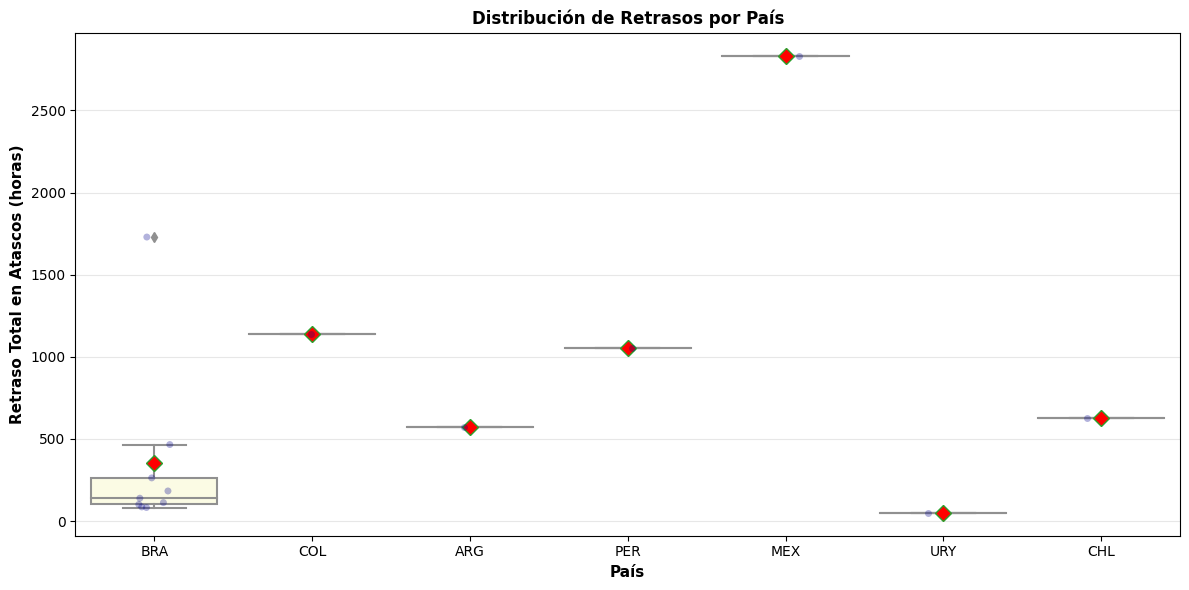

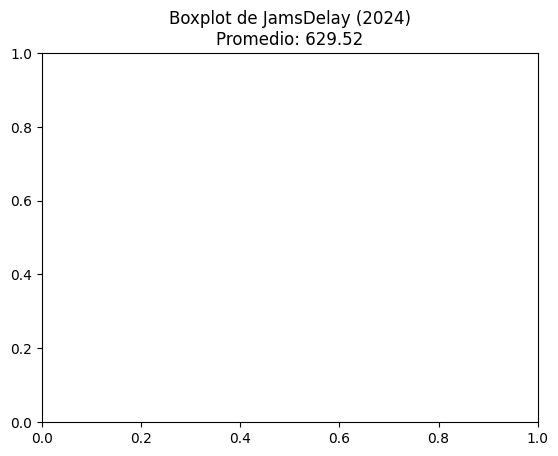

In [16]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

if merged['country'].nunique() > 1:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=merged, x='country', y='jams_delay_total', 
               color='lightyellow', showmeans=True,
               meanprops=dict(marker='D', markerfacecolor='red', markersize=8))
    sns.stripplot(data=merged, x='country', y='jams_delay_total', 
                 color='darkblue', alpha=0.3, size=5)
    plt.xlabel('País', fontweight='bold', fontsize=11)
    plt.ylabel('Retraso Total en Atascos (horas)', fontweight='bold', fontsize=11)
    plt.title('Distribución de Retrasos por País', fontweight='bold', fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay_total'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
El boxplot estratificado por país con <code>stripplot</code> superpuesto y medias marcadas visualmente con <code>meanprops</code> personalizados es una muy buena decisión de visualización: permite ver simultáneamente la distribución, los valores individuales y la media de cada país, con mucho más contexto que el gráfico básico. 👏 Claramente fuiste más allá de lo mínimo requerido.
</div>

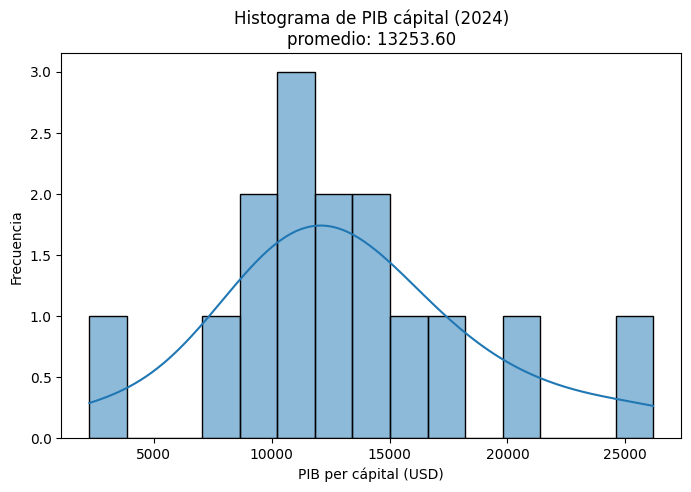

In [17]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
plt.figure(figsize=(8,5))
sns.histplot(merged['city_gdp_per_capita'],bins=15, kde=True)
mean_gdp = merged['city_gdp_per_capita'].mean()
plt.title(f'Histograma de PIB cápital (2024)\npromedio: {mean_gdp:.2f}')
plt.xlabel('PIB per cápital (USD)')
plt.ylabel('Frecuencia')
plt.show()



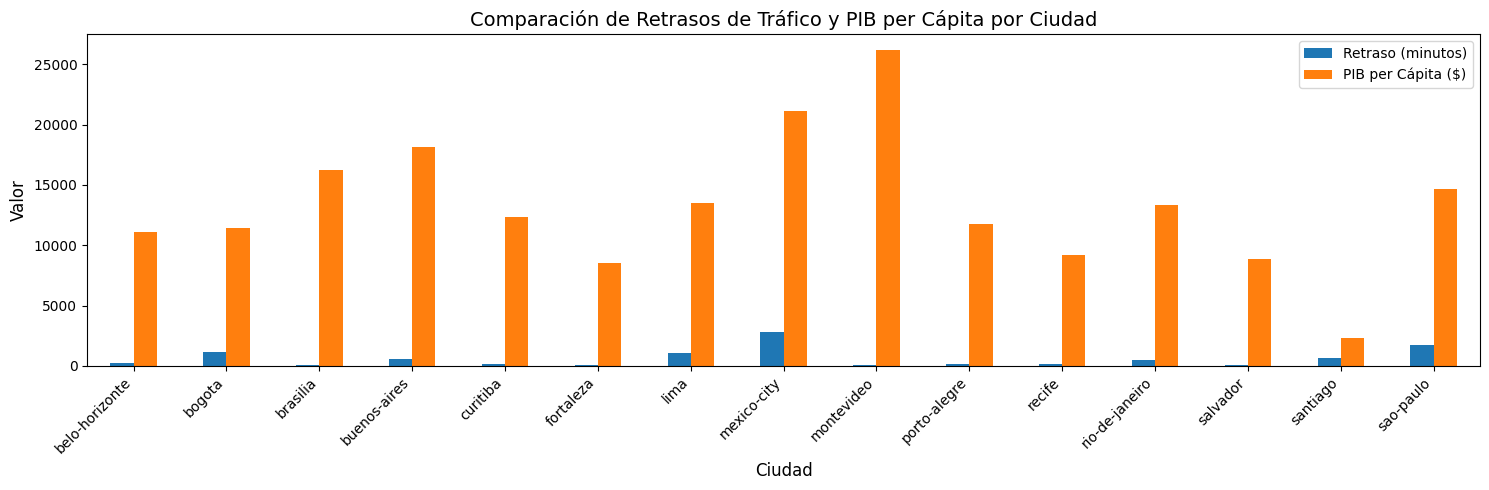

In [18]:

# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(15, 5))

merged.plot(x='city', 
           y=['jams_delay_total', 'city_gdp_per_capita'], 
           kind='bar', 
           ax=ax)

plt.title('Comparación de Retrasos de Tráfico y PIB per Cápita por Ciudad', fontsize=14)
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.legend(['Retraso (minutos)', 'PIB per Cápita ($)'], fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
En el gráfico de barras estás graficando <code>jams_delay_total</code> (en el orden de cientos de minutos) y <code>city_gdp_per_capita</code> (en decenas de miles de USD) en el <b>mismo eje Y</b>. Como las escalas son tan distintas, las barras de <code>jams_delay_total</code> quedan visualmente aplastadas frente a las de PIB y apenas se pueden leer.

Para comparar dos variables de escalas muy diferentes, te recomiendo usar un eje Y secundario con <code>secondary_y=['jams_delay_total']</code> dentro de <code>DataFrame.plot()</code>, o crear dos subplots con <code>plt.subplots()</code>. Esto haría el gráfico más legible y profesional.
</div>

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios:

Montevideo presenta un PIB superior en comparación con muchas otras ciudades y, al mismo tiempo, registra niveles de congestión vehicular casi imperceptibles. En contraste, Ciudad de México también cuenta con un PIB elevado, pero presenta una alta percepción de retraso ocasionado por el tráfico. Esto sugiere que no existe una relación directa entre el PIB de una ciudad y su nivel de congestión vehicular.

Al analizar las ciudades con mayor tráfico, parece observarse una relación más estrecha con el tamaño de su población que con su nivel de riqueza. A partir de este hallazgo, sería conveniente profundizar en el análisis de los horarios de mayor congestión e implementar políticas e incentivos que promuevan alternativas de movilidad y una mejor distribución de los desplazamientos. Algunas medidas podrían incluir el uso de bicicletas públicas, programas para compartir vehículo (carpooling), restricciones de circulación según la placa o patente y estrategias para incentivar los desplazamientos en horarios de menor demanda.

Finalmente, otro aspecto clave que debería evaluarse es la infraestructura vial y del transporte. Si bien las mejoras en este ámbito suelen requerir inversiones significativamente mayores, representan una de las alternativas con mayor impacto a largo plazo para reducir la congestión y mejorar la movilidad urbana.


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [19]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 


---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
El objetivo de este análisis fue evaluar la relación entre la movilidad urbana, representada por indicadores de congestión y tiempos de viaje, y la productividad económica, medida mediante el PIB per cápita de diferentes ciudades. Comprender esta relación permite identificar si una mayor congestión vehicular está asociada con menores niveles de productividad y apoyar la priorización de inversiones en infraestructura y políticas de movilidad.

Para ello se utilizaron variables como el Traffic Index Live, el tiempo promedio de viaje por cada 10 kilómetros, el retraso promedio (MinsDelay) y el PIB per cápita de cada ciudad. Estas variables permiten evaluar simultáneamente el desempeño económico y las condiciones de movilidad urbana.

**Cobertura de datos:**  
El análisis integra información correspondiente al año 2023 para variables económicas y registros de tráfico del año 2025, considerando 30 ciudades pertenecientes a diferentes países. La integración se realizó utilizando la ciudad como llave común entre ambos conjuntos de datos.

**Metodología (alto nivel):**  
nicialmente se realizó una etapa de limpieza y estandarización de los datos, corrigiendo formatos de fechas, convirtiendo columnas numéricas almacenadas como texto y homologando los nombres de las columnas. Posteriormente, la información de tráfico fue agregada por ciudad para obtener indicadores representativos y se integró con la información económica mediante una unión INNER JOIN, conservando únicamente las ciudades presentes en ambos conjuntos de datos.

Finalmente, se efectuó un análisis exploratorio utilizando distribuciones, detección de valores atípicos y gráficos de dispersión para identificar tendencias generales y posibles relaciones entre los indicadores de movilidad y productividad económica.

**Hallazgos iniciales:**  
Los resultados preliminares indican que no existe una relación lineal fuerte entre el PIB per cápita y los niveles de congestión vehicular. Se observan ciudades con altos niveles de productividad económica que también presentan altos niveles de congestión, mientras que otras con menor PIB muestran niveles moderados de tráfico. Esto sugiere que la congestión urbana está influenciada por múltiples factores, como el tamaño de la población, la densidad urbana, la infraestructura vial y las políticas de transporte, además del desempeño económico.

Asimismo, se identifican algunas ciudades con comportamientos atípicos (outliers) que deberían analizarse individualmente, ya que presentan niveles de congestión significativamente superiores o inferiores a los esperados respecto a su nivel económico.

**Recomendaciones**  
Se recomienda complementar este análisis incorporando variables como la población, la densidad urbana, la extensión de la red vial, el uso del transporte público y el crecimiento del parque automotor, con el fin de explicar de manera más precisa las diferencias observadas entre las ciudades. Asimismo, es importante validar que ambas fuentes de información correspondan al mismo periodo temporal para reducir posibles sesgos en la interpretación de los resultados.

Adicionalmente, se recomienda analizar los horarios en los que se presentan los mayores niveles de congestión vehicular, ya que esta información puede servir como base para diseñar e implementar medidas temporales de gestión de la movilidad durante las horas pico. Entre estas medidas se encuentran restricciones de circulación en franjas horarias específicas, incentivos para compartir vehículo y estrategias que promuevan el uso de medios de transporte alternativos, como las bicicletas públicas o la movilidad activa.

El fomento de estos medios de transporte no solo podría contribuir a disminuir la congestión y mejorar los tiempos de desplazamiento, sino que también generaría beneficios adicionales para la población, como el incremento de la actividad física, la reducción de enfermedades asociadas al sedentarismo, la disminución de emisiones contaminantes y una mejora general en la calidad de vida urbana. Estas acciones permitirían abordar el problema de la movilidad desde una perspectiva integral, combinando beneficios económicos, ambientales y de salud pública.

con la información disponible aún no puede determinarse objetivamente. Para responderla es necesario calcular la correlación entre los indicadores de congestión y el PIB per cápita, así como comparar simultáneamente el nivel de congestión y la productividad de cada ciudad. Solo después de ese análisis podría concluirse, con evidencia estadística, si Bogotá, Lima, Buenos Aires u otra ciudad constituye la principal prioridad de inversión.


<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
Tu resumen ejecutivo tiene un nivel de redacción muy sólido en general: explicas la metodología con claridad, usas lenguaje no causal y aportas recomendaciones concretas que van más allá del análisis mismo (bicicletas públicas, movilidad activa, beneficios de salud). Sin embargo, encontré un error factual importante en la sección <b>"Cobertura de datos"</b> que debes corregir:

Escribiste: <i>"El análisis integra información correspondiente al año 2023 para variables económicas y registros de tráfico del año 2025"</i>. Esto no es correcto: tanto el filtro de tráfico como el de economía usan el año <b>2024</b> (puedes confirmarlo en tus celdas 21 y 22, donde filtras por <code>year == 2024</code>). El origen del dato 2023/2025 probablemente viene de haber mirado el <code>.head()</code> sin filtrar, que sí muestra filas de 2023 y 2025 — pero lo que entra al análisis es exclusivamente 2024.

Además, en esa misma sección dices "30 ciudades" cuando el <code>merged</code> final (tras el inner join) tiene <b>15 ciudades</b> latinoamericanas.

Por favor corrige ambos datos para que el reporte sea preciso.

Sobre la pregunta de ciudad prioritaria: tu decisión de no responderla sin más evidencia estadística es honesta e intelectualmente correcta, y lo que propones (calcular correlación) es el paso natural siguiente. Para esta entrega, sin embargo, te invito a hacer al menos una elección preliminar basada en lo que ya tienes (los datos de <code>merged</code> que ya calculaste, ordenados por congestión y PIB), aclarando explícitamente que es una recomendación exploratoria pendiente de validación estadística. Eso haría tu recomendación accionable sin que pierdas el rigor que demostraste.
</div>